In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
TICKER = "AAPL" 

end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
start_date = (pd.Timestamp.today() - pd.DateOffset(years=10)).strftime('%Y-%m-%d')
print(f"Downloading data for {TICKER} from {start_date} to {end_date}...")
df = yf.Ticker(TICKER).history(start=start_date, end=end_date)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2513, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2016-06-17 00:00:00-04:00,21.995512,22.002341,21.695014,21.701843,244032800
2016-06-20 00:00:00-04:00,21.854358,21.984118,21.633538,21.649473,137647600
2016-06-21 00:00:00-04:00,21.613059,21.934044,21.553870,21.833879,142185600
2016-06-22 00:00:00-04:00,21.911280,22.056976,21.706395,21.751926,116876400
2016-06-23 00:00:00-04:00,21.840704,21.920381,21.683625,21.877127,128960800


In [6]:
features = ['Open', 'High', 'Low', 'Volume']
df['Next_Close'] = df['Close'].shift(-1)
df.dropna(inplace=True)
X = df[features]
y = df['Next_Close']
print("Features shape:", X.shape)
print("Target shape:", y.shape)
df[['Close', 'Next_Close']].sample(5)

Features shape: (2512, 4)
Target shape: (2512,)


,Close,Next_Close
Date,,
2019-03-18 00:00:00-04:00,44.802265,44.447227
2018-06-18 00:00:00-04:00,44.470116,43.751476
2019-03-06 00:00:00-05:00,41.585415,41.104099
2017-05-18 00:00:00-04:00,35.390671,35.511322
2018-05-15 00:00:00-04:00,43.928185,44.338161


In [7]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"Test period:  {X_test.index[0].date()} to {X_test.index[-1].date()}")

Train period: 2016-06-17 to 2024-06-11
Test period:  2024-06-12 to 2026-06-15


In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Models trained successfully")

Models trained successfully


In [9]:
mae = mean_absolute_error(y_test, lr_preds)
rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
r2 = r2_score(y_test, lr_preds)
print(f"\n📊 Linear Regression Performance:")
print(f"  MAE : ${mae:.2f}")
print(f"  RMSE: ${rmse:.2f}")
print(f"  R²  : {r2:.4f}")


📊 Linear Regression Performance:
  MAE : $3.09
  RMSE: $4.32
  R²  : 0.9762


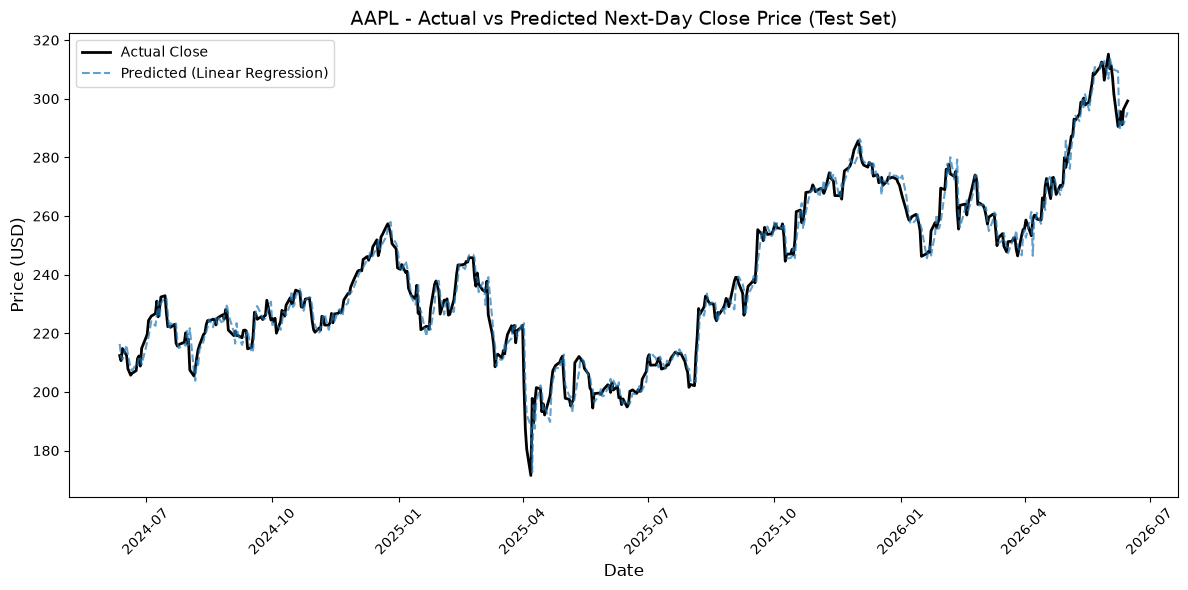

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Close', linewidth=2, color='black')
plt.plot(y_test.index, lr_preds, label='Predicted (Linear Regression)', alpha=0.7, linestyle='--')

plt.title(f'{TICKER} - Actual vs Predicted Next-Day Close Price (Test Set)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

: 